# Pożary Lasów – Predykcja Powierzchni

Celem projektu jest przewidywanie powierzchni pożaru lasu (w hektarach) na podstawie danych meteorologicznych i wskaźników pożarowych FWI (Fire Weather Index). Dane pochodzą z parku narodowego Montesinho w Portugalii.

**Zmienne wejściowe:** X, Y (współrzędne mapy), miesiąc, dzień tygodnia, FFMC, DMC, DC, ISI, temperatura, wilgotność względna (RH), wiatr, deszcz.  
**Zmienna docelowa:** `area` – powierzchnia pożaru w hektarach.

# Ładowanie Bibliotek

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

sns.set()

# Import danych

In [2]:
df_raw = pd.read_csv('fires.csv')   # Wczytujemy do df_raw, by nie modyfikować oryginału
df_test = pd.read_csv('fires_test.csv')

# Eksploracja danych (EDA)

Zanim przejdziemy do modelowania, warto zrozumieć strukturę danych: rozkłady zmiennych, brakujące wartości i korelacje.

In [3]:
print(f"Rozmiar zbioru treningowego: {df_raw.shape}")
print(f"Rozmiar zbioru testowego:    {df_test.shape}")
df_raw.head()

Rozmiar zbioru treningowego: (467, 13)
Rozmiar zbioru testowego:    (50, 12)


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,3,5,mar,tue,88.1,25.7,67.6,3.8,14.9,38,2.7,0.0,0.00
1,3,4,aug,mon,91.5,145.4,608.2,10.7,10.3,74,2.2,0.0,0.00
2,7,4,aug,sun,94.8,108.3,647.1,17.0,16.4,47,1.3,0.0,1.56
3,9,9,feb,thu,84.2,6.8,26.6,7.7,6.7,79,3.1,0.0,0.00
4,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.00


In [4]:
print("Brakujące wartości (train):")
print(df_raw.isnull().sum())
print("\nBrakujące wartości (test):")
print(df_test.isnull().sum())

Brakujące wartości (train):
X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
area     0
dtype: int64

Brakujące wartości (test):
X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
dtype: int64


In [5]:
pd.set_option('display.max_columns', None)
df_raw.describe()

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
count,467.000000,467.000000,467.000000,467.000000,467.000000,467.000000,467.000000,467.000000,467.000000,467.000000,467.000000
mean,4.674518,4.314775,90.530621,111.988651,550.702141,9.019058,18.808137,44.743041,4.041970,0.010278,13.148116
std,2.318301,1.243634,5.742648,64.921742,246.072255,4.641102,5.831719,16.529669,1.781315,0.097508,66.382225
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.900000,0.000000,0.000000
25%,3.000000,4.000000,90.200000,70.250000,440.300000,6.350000,15.450000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,664.200000,8.400000,19.200000,42.000000,4.000000,0.000000,0.410000
75%,7.000000,5.000000,92.850000,142.400000,714.100000,10.900000,22.800000,54.000000,5.150000,0.000000,6.330000
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,1.400000,1090.840000


### Rozkład zmiennej docelowej `area`

Zmienna `area` jest silnie prawoskośna – większość pożarów ma powierzchnię 0 ha, a nieliczne osiągają ponad 1000 ha. Dlatego zastosujemy transformację `log1p(area)`, która stabilizuje wariancję i zbliża rozkład do normalnego (co jest korzystne dla regresji liniowej).

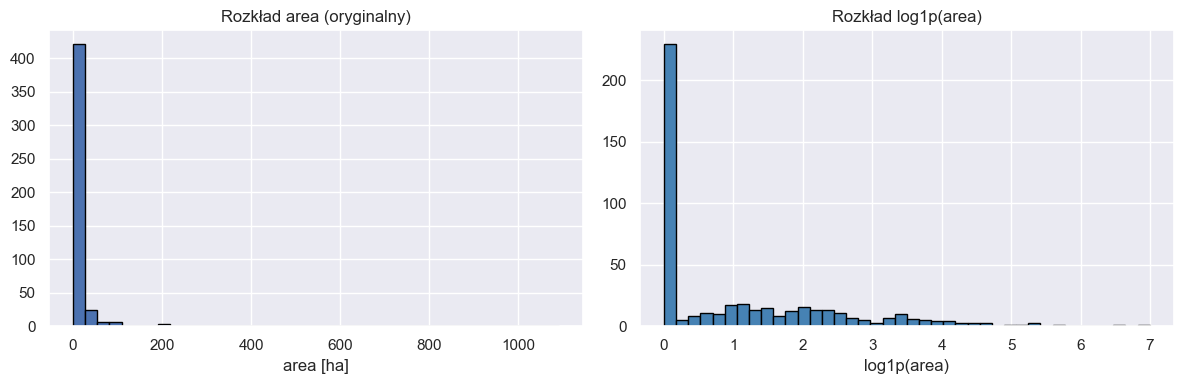

Procent pożarów o area=0: 48.6%


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_raw['area'], bins=40, edgecolor='black')
axes[0].set_title('Rozkład area (oryginalny)')
axes[0].set_xlabel('area [ha]')

axes[1].hist(np.log1p(df_raw['area']), bins=40, edgecolor='black', color='steelblue')
axes[1].set_title('Rozkład log1p(area)')
axes[1].set_xlabel('log1p(area)')

plt.tight_layout()
plt.show()

print(f"Procent pożarów o area=0: {(df_raw['area'] == 0).mean():.1%}")

### Macierz korelacji (cechy numeryczne)

Sprawdzamy korelacje między zmiennymi numerycznymi a `log1p(area)`, by ocenić siłę zależności liniowych.

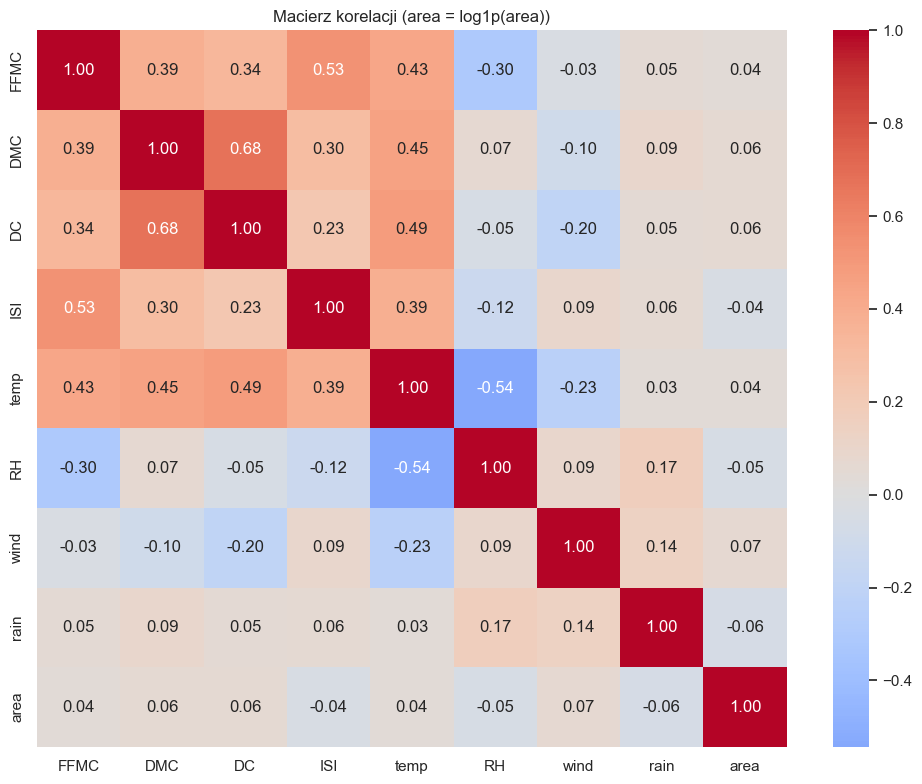

In [7]:
numeric_cols = ['FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain', 'area']
df_corr = df_raw[numeric_cols].copy()
df_corr['area'] = np.log1p(df_corr['area'])

plt.figure(figsize=(10, 8))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Macierz korelacji (area = log1p(area))')
plt.tight_layout()
plt.show()

### Rozkład pożarów według miesiąca

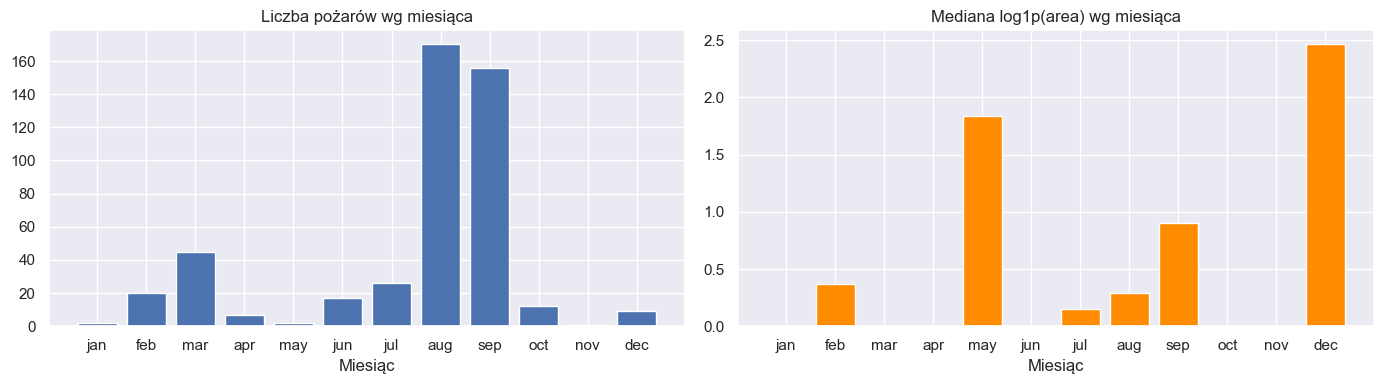

In [8]:
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Liczba pożarów
month_counts = df_raw['month'].value_counts().reindex(month_order)
axes[0].bar(month_counts.index, month_counts.values)
axes[0].set_title('Liczba pożarów wg miesiąca')
axes[0].set_xlabel('Miesiąc')

# Mediana log1p(area)
month_area = df_raw.groupby('month')['area'].apply(lambda x: np.log1p(x).median()).reindex(month_order)
axes[1].bar(month_area.index, month_area.values, color='darkorange')
axes[1].set_title('Mediana log1p(area) wg miesiąca')
axes[1].set_xlabel('Miesiąc')

plt.tight_layout()
plt.show()

# Przygotowanie danych

Kroki:
1. **One-hot encoding** kolumn `month` i `day` – przekształcamy zmienne kategoryczne na binarne.
2. **Transformacja log1p(area)** – stabilizuje rozkład zmiennej docelowej.
3. **Wersja zredukowana** – tworzymy `df2` bez kolumn dnia/miesiąca, by porównać wpływ tych cech.

> Uwaga: pracujemy na kopii `df_raw`, by transformacje nie nawarstwiały się przy ponownym uruchomieniu komórek.

In [9]:
# Pracujemy na kopii – zapobiega wielokrotnemu nakładaniu log1p
df = df_raw.copy()

# One-hot encoding
df = pd.get_dummies(df, columns=['month', 'day'])
df_test = pd.get_dummies(df_test, columns=['month', 'day'])

# Transformacja zmiennej docelowej (log1p stabilizuje silnie prawoskośny rozkład)
df['area'] = np.log1p(df['area'])

print(f"Kolumny po encodingu: {df.shape[1]}")
df.head(3)

Kolumny po encodingu: 30


,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,month_apr,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_fri,day_mon,day_sat,day_sun,day_thu,day_tue,day_wed
0,3,5,88.1,25.7,67.6,3.8,14.9,38,2.7,0.0,0.000000,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False
1,3,4,91.5,145.4,608.2,10.7,10.3,74,2.2,0.0,0.000000,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
2,7,4,94.8,108.3,647.1,17.0,16.4,47,1.3,0.0,0.940007,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False


In [10]:
# Wersja zredukowana: tylko cechy numeryczne (bez dummy'ów dnia/miesiąca)
# Pozwala sprawdzić, czy informacja czasowa faktycznie poprawia predykcję
day_month_cols = [c for c in df.columns if c.startswith('day_') or c.startswith('month_')]
df2 = df.drop(columns=day_month_cols)

# Budowanie modelu

Trenujemy 3 typy modeli (Regresja Liniowa, Ridge, Lasso) w dwóch wariantach cech (pełny / zredukowany). Dla Ridge i Lasso porównujemy wersje bazowe (arbitralne alpha) oraz strojone przez cross-validation.

**Skalowanie:** `StandardScaler` dopasowujemy wyłącznie na danych treningowych i aplikujemy do testowych – zapobiega to wyciekowi danych (data leakage).

In [11]:
X = df.drop('area', axis=1)
y = df['area']
X2 = df2.drop('area', axis=1)
y2 = df2['area']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

In [13]:
# fit_transform tylko na zbiorze treningowym – unika data leakage
scaler_full = StandardScaler()
X_train_scaled = scaler_full.fit_transform(X_train)
X_test_scaled = scaler_full.transform(X_test)

scaler_reduced = StandardScaler()
X_train_scaled2 = scaler_reduced.fit_transform(X_train2)
X_test_scaled2 = scaler_reduced.transform(X_test2)

### Pomocnicza funkcja metryk

Oceniamy modele za pomocą RMSE, MAE i R². RMSE jest wrażliwy na duże błędy, MAE podaje średni bezwzględny błąd, a R² mówi ile wariancji model wyjaśnia.

In [14]:
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{name:<30} RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}")
    return rmse

### Regresja Liniowa

In [15]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
rmse_lr = evaluate("Linear Full", y_test, lr_model.predict(X_test_scaled))

lr_model2 = LinearRegression()
lr_model2.fit(X_train_scaled2, y_train2)
rmse_lr2 = evaluate("Linear Reduced", y_test2, lr_model2.predict(X_test_scaled2))

Linear Full                    RMSE=1.4125  MAE=1.1119  R²=0.0195
Linear Reduced                 RMSE=1.4098  MAE=1.1074  R²=0.0233


### Ridge

Ridge (regularyzacja L2) zmniejsza współczynniki, ale ich nie zeruje. Wartość bazowa `alpha=1.0` to punkt wyjścia; właściwe strojenie przeprowadzamy przez `RidgeCV`. Oba warianty używają tego samego kryterium (`neg_mean_squared_error`) dla spójności porównania.

In [16]:
# Bazowe modele Ridge (alpha=1.0 jako punkt odniesienia)
ridge_base = Ridge(alpha=1.0)
ridge_base.fit(X_train_scaled, y_train)
rmse_ridge = evaluate("Ridge Full (Base)", y_test, ridge_base.predict(X_test_scaled))

ridge_base2 = Ridge(alpha=1.0)
ridge_base2.fit(X_train_scaled2, y_train2)
rmse_ridge2 = evaluate("Ridge Reduced (Base)", y_test2, ridge_base2.predict(X_test_scaled2))

Ridge Full (Base)              RMSE=1.4122  MAE=1.1110  R²=0.0199
Ridge Reduced (Base)           RMSE=1.4097  MAE=1.1073  R²=0.0233


In [17]:
alphas_to_test = np.logspace(-4, 2, 100)

In [18]:
# Strojenie przez CV – oba warianty używają tego samego scoring dla porównywalności
ridge_cv = RidgeCV(alphas=alphas_to_test, scoring='neg_mean_squared_error', cv=5)
ridge_cv.fit(X_train_scaled, y_train)
rmse_ridge_tuned = evaluate("Ridge Full (Tuned)", y_test, ridge_cv.predict(X_test_scaled))
print(f"  → Dobrane alpha (full): {ridge_cv.alpha_:.4f}")

ridge_cv2 = RidgeCV(alphas=alphas_to_test, scoring='neg_mean_squared_error', cv=5)
ridge_cv2.fit(X_train_scaled2, y_train2)
rmse_ridge2_tuned = evaluate("Ridge Reduced (Tuned)", y_test2, ridge_cv2.predict(X_test_scaled2))
print(f"  → Dobrane alpha (reduced): {ridge_cv2.alpha_:.4f}")

Ridge Full (Tuned)             RMSE=1.4003  MAE=1.1069  R²=0.0364
  → Dobrane alpha (full): 100.0000
Ridge Reduced (Tuned)          RMSE=1.4094  MAE=1.1179  R²=0.0237
  → Dobrane alpha (reduced): 100.0000


### Lasso

Lasso (regularyzacja L1) potrafi zerować współczynniki, pełniąc jednocześnie rolę selekcji cech. Sprawdzamy, ile cech faktycznie zostaje wybranych po strojeniu.

In [19]:
# Bazowe modele Lasso (alpha=0.1 jako punkt odniesienia)
lasso_base = Lasso(alpha=0.1)
lasso_base.fit(X_train_scaled, y_train)
rmse_lasso = evaluate("Lasso Full (Base)", y_test, lasso_base.predict(X_test_scaled))

lasso_base2 = Lasso(alpha=0.1)
lasso_base2.fit(X_train_scaled2, y_train2)
rmse_lasso2 = evaluate("Lasso Reduced (Base)", y_test2, lasso_base2.predict(X_test_scaled2))

Lasso Full (Base)              RMSE=1.4032  MAE=1.1327  R²=0.0323
Lasso Reduced (Base)           RMSE=1.4263  MAE=1.1548  R²=0.0002


In [20]:
lasso_cv = LassoCV(alphas=alphas_to_test, cv=5)
lasso_cv.fit(X_train_scaled, y_train)
rmse_lasso_tuned = evaluate("Lasso Full (Tuned)", y_test, lasso_cv.predict(X_test_scaled))
nonzero_full = np.sum(lasso_cv.coef_ != 0)
print(f"  → Dobrane alpha: {lasso_cv.alpha_:.4f} | Cechy niezerowe: {nonzero_full}/{X_train.shape[1]}")

lasso_cv2 = LassoCV(alphas=alphas_to_test, cv=5)
lasso_cv2.fit(X_train_scaled2, y_train2)
rmse_lasso2_tuned = evaluate("Lasso Reduced (Tuned)", y_test2, lasso_cv2.predict(X_test_scaled2))
nonzero_reduced = np.sum(lasso_cv2.coef_ != 0)
print(f"  → Dobrane alpha: {lasso_cv2.alpha_:.4f} | Cechy niezerowe: {nonzero_reduced}/{X_train2.shape[1]}")

Lasso Full (Tuned)             RMSE=1.4062  MAE=1.1359  R²=0.0282
  → Dobrane alpha: 0.1072 | Cechy niezerowe: 3/29
Lasso Reduced (Tuned)          RMSE=1.4266  MAE=1.1557  R²=-0.0001
  → Dobrane alpha: 100.0000 | Cechy niezerowe: 0/10


# Porównanie modeli i wybór najlepszego


✅ Najlepszy model: Ridge Full (Tuned) (RMSE = 1.4003)


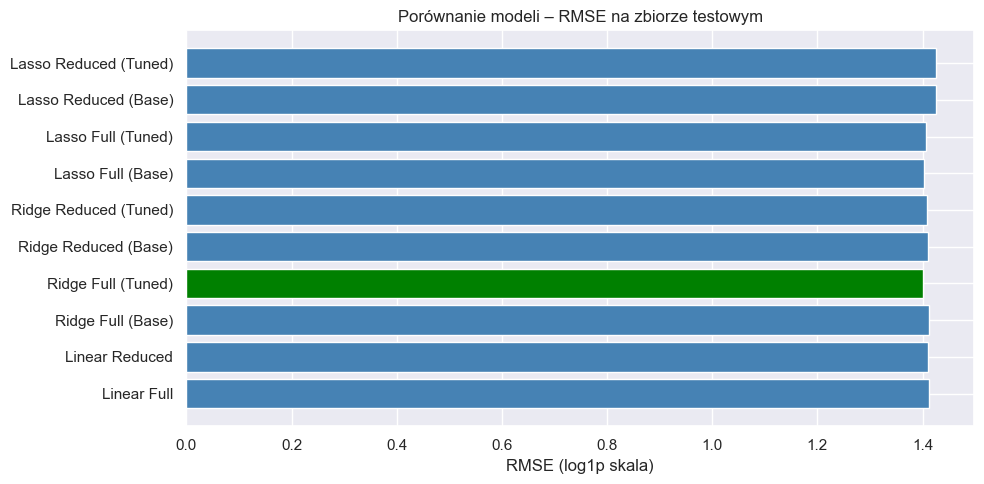

In [21]:
models_rmse = {
    "Linear Full":         rmse_lr,
    "Linear Reduced":      rmse_lr2,
    "Ridge Full (Base)":   rmse_ridge,
    "Ridge Full (Tuned)":  rmse_ridge_tuned,
    "Ridge Reduced (Base)": rmse_ridge2,
    "Ridge Reduced (Tuned)": rmse_ridge2_tuned,
    "Lasso Full (Base)":   rmse_lasso,
    "Lasso Full (Tuned)":  rmse_lasso_tuned,
    "Lasso Reduced (Base)": rmse_lasso2,
    "Lasso Reduced (Tuned)": rmse_lasso2_tuned,
}

best_model_name = min(models_rmse, key=models_rmse.get)
best_rmse_value = models_rmse[best_model_name]
print(f"\n✅ Najlepszy model: {best_model_name} (RMSE = {best_rmse_value:.4f})")

# Wykres porównania RMSE
plt.figure(figsize=(10, 5))
colors = ['green' if k == best_model_name else 'steelblue' for k in models_rmse]
plt.barh(list(models_rmse.keys()), list(models_rmse.values()), color=colors)
plt.xlabel('RMSE (log1p skala)')
plt.title('Porównanie modeli – RMSE na zbiorze testowym')
plt.tight_layout()
plt.show()

### Analiza reszt najlepszego modelu

Sprawdzamy, czy reszty są losowo rozłożone (brak wzorców = dobry model) i jak wygląda ich rozkład.

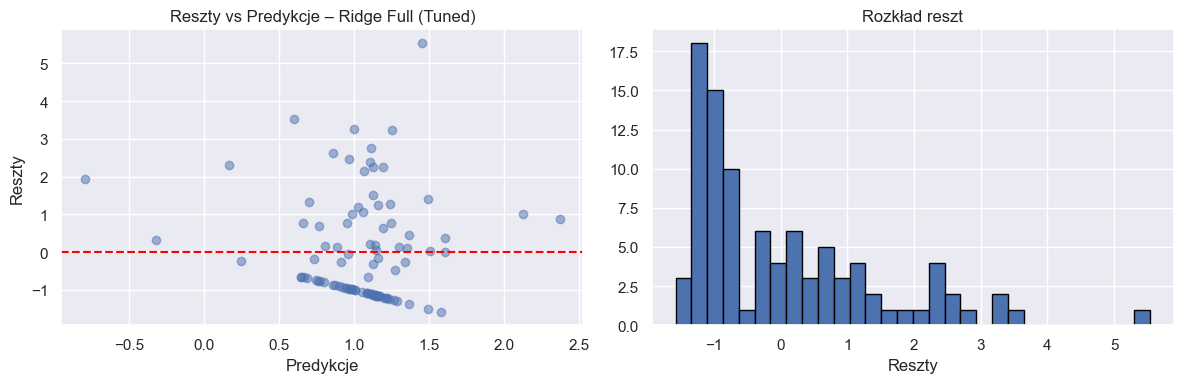

In [22]:
# Dynamiczne wybranie najlepszego modelu do analizy reszt
best_model_objects = {
    "Linear Full":         (lr_model, X_test_scaled, y_test),
    "Linear Reduced":      (lr_model2, X_test_scaled2, y_test2),
    "Ridge Full (Base)":   (ridge_base, X_test_scaled, y_test),
    "Ridge Full (Tuned)":  (ridge_cv, X_test_scaled, y_test),
    "Ridge Reduced (Base)": (ridge_base2, X_test_scaled2, y_test2),
    "Ridge Reduced (Tuned)": (ridge_cv2, X_test_scaled2, y_test2),
    "Lasso Full (Base)":   (lasso_base, X_test_scaled, y_test),
    "Lasso Full (Tuned)":  (lasso_cv, X_test_scaled, y_test),
    "Lasso Reduced (Base)": (lasso_base2, X_test_scaled2, y_test2),
    "Lasso Reduced (Tuned)": (lasso_cv2, X_test_scaled2, y_test2),
}

best_obj, best_X, best_y = best_model_objects[best_model_name]
best_preds = best_obj.predict(best_X)
residuals = best_y - best_preds

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(best_preds, residuals, alpha=0.5)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predykcje')
axes[0].set_ylabel('Reszty')
axes[0].set_title(f'Reszty vs Predykcje – {best_model_name}')

axes[1].hist(residuals, bins=30, edgecolor='black')
axes[1].set_xlabel('Reszty')
axes[1].set_title('Rozkład reszt')

plt.tight_layout()
plt.show()

# Generowanie predykcji końcowych

Używamy **dynamicznie wybranego** najlepszego modelu. Predykcje są w skali `log1p`, więc odwracamy transformację przez `expm1`.

In [23]:
# Dopasowanie kolumn zbioru testowego do kolumn treningowych
# (fill_value=0 dla kolumn miesiąc/dzień nieobecnych w df_test)
X_final = df_test.reindex(columns=X.columns, fill_value=0)
X_final_scaled = scaler_full.transform(X_final)

In [24]:
# Dynamicznie wybieramy model i scaler odpowiedni dla najlepszego wariantu
best_model_obj, best_X_data, _ = best_model_objects[best_model_name]

# Jeśli najlepszy model pochodzi z wersji zredukowanej, użyj scaler_reduced i X_final2
if 'Reduced' in best_model_name:
    X_final_for_pred = df_test.reindex(columns=X2.columns, fill_value=0)
    X_final_for_pred_scaled = scaler_reduced.transform(X_final_for_pred)
else:
    X_final_for_pred_scaled = X_final_scaled

final_preds_log = best_model_obj.predict(X_final_for_pred_scaled)
final_preds_hectares = np.expm1(final_preds_log)  # odwrócenie log1p

print(f"Model użyty do predykcji: {best_model_name}")
print(f"Predykcje (pierwsze 5): {np.round(final_preds_hectares[:5], 2)}")

Model użyty do predykcji: Ridge Full (Tuned)
Predykcje (pierwsze 5): [0.75 1.78 2.95 1.97 1.87]


In [25]:
submission = pd.DataFrame({'area': final_preds_hectares})
submission.to_csv('submission.csv', index=False)
print(f"Zapisano {len(submission)} predykcji do 'submission.csv'")
submission.describe()

Zapisano 50 predykcji do 'submission.csv'


,area
count,50.000000
mean,1.773926
std,0.783423
min,-0.999183
25%,1.423622
50%,1.841897
75%,2.242955
max,3.282006
